# **<center> SVM Model — Multi-Output Sentiment Analysis <center>**

## **Import Libraries**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score

## **Load Data**

In [44]:
df_train = pd.read_csv('crawl_only_train.csv')
df_test  = pd.read_csv('crawl_only_test.csv')

print(f"Train size : {df_train.shape}")
print(f"Test size  : {df_test.shape}")

Train size : (13224, 9)
Test size  : (1889, 9)


In [45]:
df_train.head(5)

,review_id,Review,rating,vệ sinh_label,đồ ăn thức uống_label,khách sạn_label,vị trí_label,phòng ốc_label,dịch vụ_label
0,834149749,phòng nhỏ gia_đình mình check out sớm để lại v...,5.0,0,0,2,0,2,2
1,344704376,vợ_chồng tôi ở đây một đêm trước khi đi hội_an...,10.0,1,0,1,0,1,1
2,920704244,dịch_vụ tốt nha em ơi,10.0,0,0,1,0,0,0
3,646347967,chỗ này oai lắm nhé gần biển đi ra có 5 mình l...,8.0,1,0,0,1,0,0
4,920709757,rất thoải_mái và nhân_viên tuyệt_vời,10.0,0,0,1,0,0,1


In [46]:
# Define columns
TARGET_COLS = [
    'vệ sinh_label',
    'đồ ăn thức uống_label',
    'khách sạn_label',
    'vị trí_label',
    'phòng ốc_label',
    'dịch vụ_label',
]

LABEL_NAMES = {
    0: 'Không tồn tại',
    1: 'Tích cực',
    2: 'Tiêu cực',
}

# Separate X, y
X_train = df_train['Review']
y_train = df_train[TARGET_COLS]

X_test  = df_test['Review']
y_test  = df_test[TARGET_COLS]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape},  y_test : {y_test.shape}")

X_train: (13224,), y_train: (13224, 6)
X_test : (1889,),  y_test : (1889, 6)


In [47]:
# Check the label distribution on the training set
for col in TARGET_COLS:
    print(f"\n--- {col} ---")
    counts = y_train[col].value_counts().sort_index()
    for cls_id, cnt in counts.items():
        pct = cnt / len(y_train) * 100
        print(f"  Class {cls_id} ({LABEL_NAMES.get(cls_id, '?')}): {cnt:>5d}  ({pct:5.1f}%)")


--- vệ sinh_label ---
  Class 0 (Không tồn tại):  9309  ( 70.4%)
  Class 1 (Tích cực):  3155  ( 23.9%)
  Class 2 (Tiêu cực):   760  (  5.7%)

--- đồ ăn thức uống_label ---
  Class 0 (Không tồn tại): 10960  ( 82.9%)
  Class 1 (Tích cực):  1731  ( 13.1%)
  Class 2 (Tiêu cực):   533  (  4.0%)

--- khách sạn_label ---
  Class 0 (Không tồn tại):  3108  ( 23.5%)
  Class 1 (Tích cực):  9074  ( 68.6%)
  Class 2 (Tiêu cực):  1042  (  7.9%)

--- vị trí_label ---
  Class 0 (Không tồn tại):  8436  ( 63.8%)
  Class 1 (Tích cực):  4507  ( 34.1%)
  Class 2 (Tiêu cực):   281  (  2.1%)

--- phòng ốc_label ---
  Class 0 (Không tồn tại):  7655  ( 57.9%)
  Class 1 (Tích cực):  3914  ( 29.6%)
  Class 2 (Tiêu cực):  1655  ( 12.5%)

--- dịch vụ_label ---
  Class 0 (Không tồn tại):  6897  ( 52.2%)
  Class 1 (Tích cực):  5782  ( 43.7%)
  Class 2 (Tiêu cực):   545  (  4.1%)


## **TF-IDF Configuration and Vectorization**

* `ngram_range=(1, 2)`: Uses both unigrams and bigrams to capture individual words and short phrases, improving the model's ability to understand local context (e.g., "không tốt", "rất sạch").
* `max_features=50000`: Limits the vocabulary size to the top 50,000 most important terms, helping control dimensionality and improve training efficiency.
* `sublinear_tf=True`: Applies logarithmic scaling (`1 + log(tf)`) instead of raw term frequency, reducing the dominance of very frequent words within a document.
* `min_df=2`: Removes terms that appear in fewer than 2 documents, which helps eliminate noise such as rare words or typos.
* `max_df=0.95`: Removes terms that appear in more than 95% of documents, as these are likely uninformative (similar to stopwords).

**Note:** `fit` is performed only on the **training set** to avoid data leakage. The `transform` step is then applied to both training and test sets.

In [48]:
# Initialize TfidfVectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),       # unigram + bigram
    max_features=50_000,      # limit vocabulary
    sublinear_tf=True,        # log-normalization for term frequency
    min_df=2,                 # remove words that are too rare
    max_df=0.95,              # remove words that appear in more than 95% of documents (stopword-like)
)

# Fit on training set, transform on training and test sets
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Vocabulary size      : {len(tfidf.vocabulary_):,}")
print(f"X_train_tfidf shape  : {X_train_tfidf.shape}")
print(f"X_test_tfidf shape   : {X_test_tfidf.shape}")

Vocabulary size      : 34,498
X_train_tfidf shape  : (13224, 34498)
X_test_tfidf shape   : (1889, 34498)


## **Training SVM Model**

* Use `SVC(kernel='linear', class_weight='balanced')` as the base estimator.
  * `kernel='linear'`: Effective for TF-IDF text data, which is typically high-dimensional and sparse.
  * `class_weight='balanced'`: Automatically adjusts class weights inversely proportional to class frequencies → helps the model pay more attention to minority classes (Class 0, 1, 2).

* Wrap the model with `MultiOutputClassifier` to train 6 independent classifiers (one classifier per target column).
  * Each classifier handles one label separately.
  * Since each label has 3 classes (0, 1, 2), the underlying `SVC` internally uses the One-vs-Rest (OvR) strategy to handle multi-class classification.

In [49]:
# Initialize base estimator
svm_base = SVC(
    kernel='linear',
    class_weight='balanced',  # data imbalance handling
    random_state=42,
)
X_train_tfidf.sort_indices()

# Wrap MultiOutputClassifier
model = MultiOutputClassifier(
    estimator=svm_base,
    n_jobs=-1,                 
)

print("Training begins")
model.fit(X_train_tfidf, y_train)
print("Training is complete")

Training begins
Training is complete


## **Prediction and Evaluation**

In [50]:
# Predict on test set
y_pred = model.predict(X_test_tfidf)
print(f"Prediction shape: {y_pred.shape}")

# Save to a pickle file to preserve the original model
model_path = 'svm_model.pkl'
joblib.dump(model, model_path)
print(f"SVM model saved successfully at: {model_path}")

Prediction shape: (1889, 6)
SVM model saved successfully at: svm_model.pkl


In [51]:
macro_f1_scores = []

for idx, col in enumerate(TARGET_COLS):
    aspect_name = col.replace('_label', '')
    y_true_col = y_test[col]
    y_pred_col = y_pred[:, idx]

    # Identify the classes that actually appear in the test set
    unique_labels = sorted(y_true_col.unique())
    target_names = [f"{lbl} - {LABEL_NAMES.get(lbl, '?')}" for lbl in unique_labels]

    report = classification_report(
        y_true_col,
        y_pred_col,
        labels=unique_labels,
        target_names=target_names,
        digits=4,
        zero_division=0,
    )

    # Calculate individual F1-macro
    report_dict = classification_report(
        y_true_col,
        y_pred_col,
        labels=unique_labels,
        output_dict=True,
        zero_division=0,
    )
    f1_macro = report_dict['macro avg']['f1-score']
    macro_f1_scores.append(f1_macro)

    print('=' * 70)
    print(f"  ASPECT: {aspect_name.upper()}")
    print(f"  F1-macro: {f1_macro:.4f}")
    print('=' * 70)
    print(report)
    print()

  ASPECT: VỆ SINH
  F1-macro: 0.8853
                   precision    recall  f1-score   support

0 - Không tồn tại     0.9678    0.9643    0.9660      1372
     1 - Tích cực     0.8961    0.9349    0.9151       415
     2 - Tiêu cực     0.8315    0.7255    0.7749       102

         accuracy                         0.9449      1889
        macro avg     0.8984    0.8749    0.8853      1889
     weighted avg     0.9447    0.9449    0.9445      1889


  ASPECT: ĐỒ ĂN THỨC UỐNG
  F1-macro: 0.8227
                   precision    recall  f1-score   support

0 - Không tồn tại     0.9789    0.9903    0.9846      1548
     1 - Tích cực     0.8598    0.8534    0.8566       266
     2 - Tiêu cực     0.7119    0.5600    0.6269        75

         accuracy                         0.9539      1889
        macro avg     0.8502    0.8012    0.8227      1889
     weighted avg     0.9516    0.9539    0.9524      1889


  ASPECT: KHÁCH SẠN
  F1-macro: 0.7036
                   precision    recall  f1-sc

In [52]:
# Average F1-macro synthesis across 6 aspects
summary = pd.DataFrame({
    'Aspect': [col.replace('_label', '') for col in TARGET_COLS],
    'F1-macro': macro_f1_scores,
})

avg_f1 = summary['F1-macro'].mean()
summary.loc[len(summary)] = ['AVERAGE', avg_f1]

print('=' * 40)
print('  Macro-Averaged F1 Score by Aspect')
print('=' * 40)
print(summary.to_string(index=False))
print(f"\nAverage F1-macro: {avg_f1:.4f}")

  Macro-Averaged F1 Score by Aspect
         Aspect  F1-macro
        vệ sinh  0.885336
đồ ăn thức uống  0.822685
      khách sạn  0.703553
         vị trí  0.817843
       phòng ốc  0.863065
        dịch vụ  0.865355
        AVERAGE  0.826306

Average F1-macro: 0.8263


## **Confusion Matrix Heatmap**

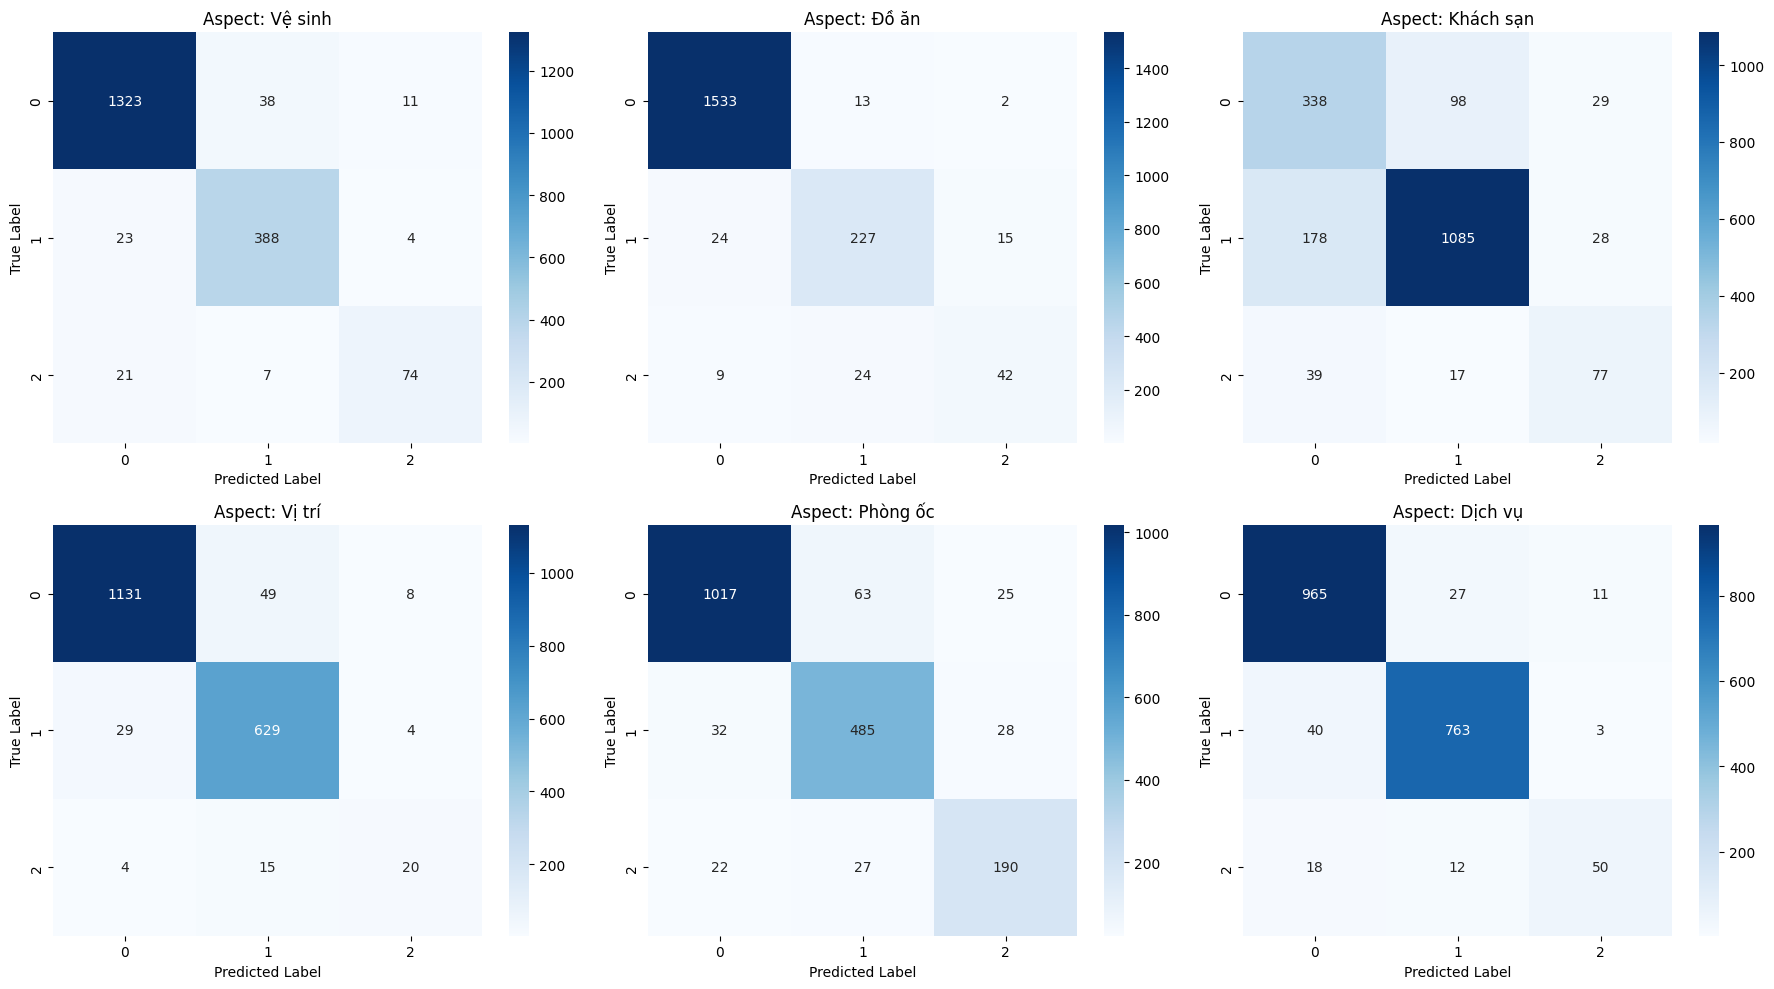

In [53]:
target_names = ['vệ sinh', 'đồ ăn', 'khách sạn', 'vị trí', 'phòng ốc', 'dịch vụ']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, aspect in enumerate(target_names):
    # Obtain the actual and predicted labels for aspect i
    y_true_i = y_test.iloc[:, i] if hasattr(y_test, 'iloc') else y_test[:, i]
    y_pred_i = y_pred[:, i]
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_true_i, y_pred_i, labels=[0, 1, 2])
    
    # Draw Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=['0', '1', '2'], yticklabels=['0', '1', '2'])
    axes[i].set_title(f"Aspect: {aspect.capitalize()}")
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

**Dominance in Detecting the Positive Class (Class 1):**
* Across all six confusion matrices, the correctly predicted cells for **Class 1 (Positive)** consistently exhibit medium to high intensity. Notably, for the *Khách sạn* aspect, the (1,1) cell shows the highest intensity across the entire visualization, surpassing even **Class 0 (Not Mentioned)**.
* This indicates a strong concentration of positive samples in the dataset. The *Khách sạn* aspect serves as the core entity that most customers explicitly comment on in their reviews. The superior performance of SVM on this class suggests that **positive lexical cues** related to overall hotel experience appear with high frequency and strong discriminative power, enabling the model to optimize the **decision boundary** for Class 1 more effectively than for other classes.

**Sparsity and Difficulty in Detecting the Negative Class (Class 2)**
* In all six confusion matrices, cells associated with **Class 2 (Negative)** have very low values and the lowest intensity.
* This is a direct consequence of **class imbalance**. The number of negative samples in the training set is the smallest, resulting in limited exposure for the model to learn representative features of negative sentiment. Consequently, the **decision region** for Class 2 becomes narrow, making it difficult for the SVM to produce confident predictions, as reflected by the low values in the confusion matrices.

**Boundary Between “Mentioned” and “Not Mentioned” (Class 0 vs. Class 1, 2):**
* Except for the *Khách sạn* aspect, in the remaining five aspects, the (0,0) cell still contains the highest density (darkest color). Most misclassifications arise from confusion between whether an aspect is **mentioned** or **not mentioned**.
* This highlights a limitation of TF-IDF when handling **implicit aspects**. When customers do not explicitly mention aspect-specific keywords (e.g., “location”, “food”) but instead provide indirect comments (e.g., “It’s very convenient here”), TF-IDF fails to capture aspect-indicative signals. As a result, the SVM incorrectly predicts **Class 0 (Not Mentioned)**.

## **Precision-Recall Curve**

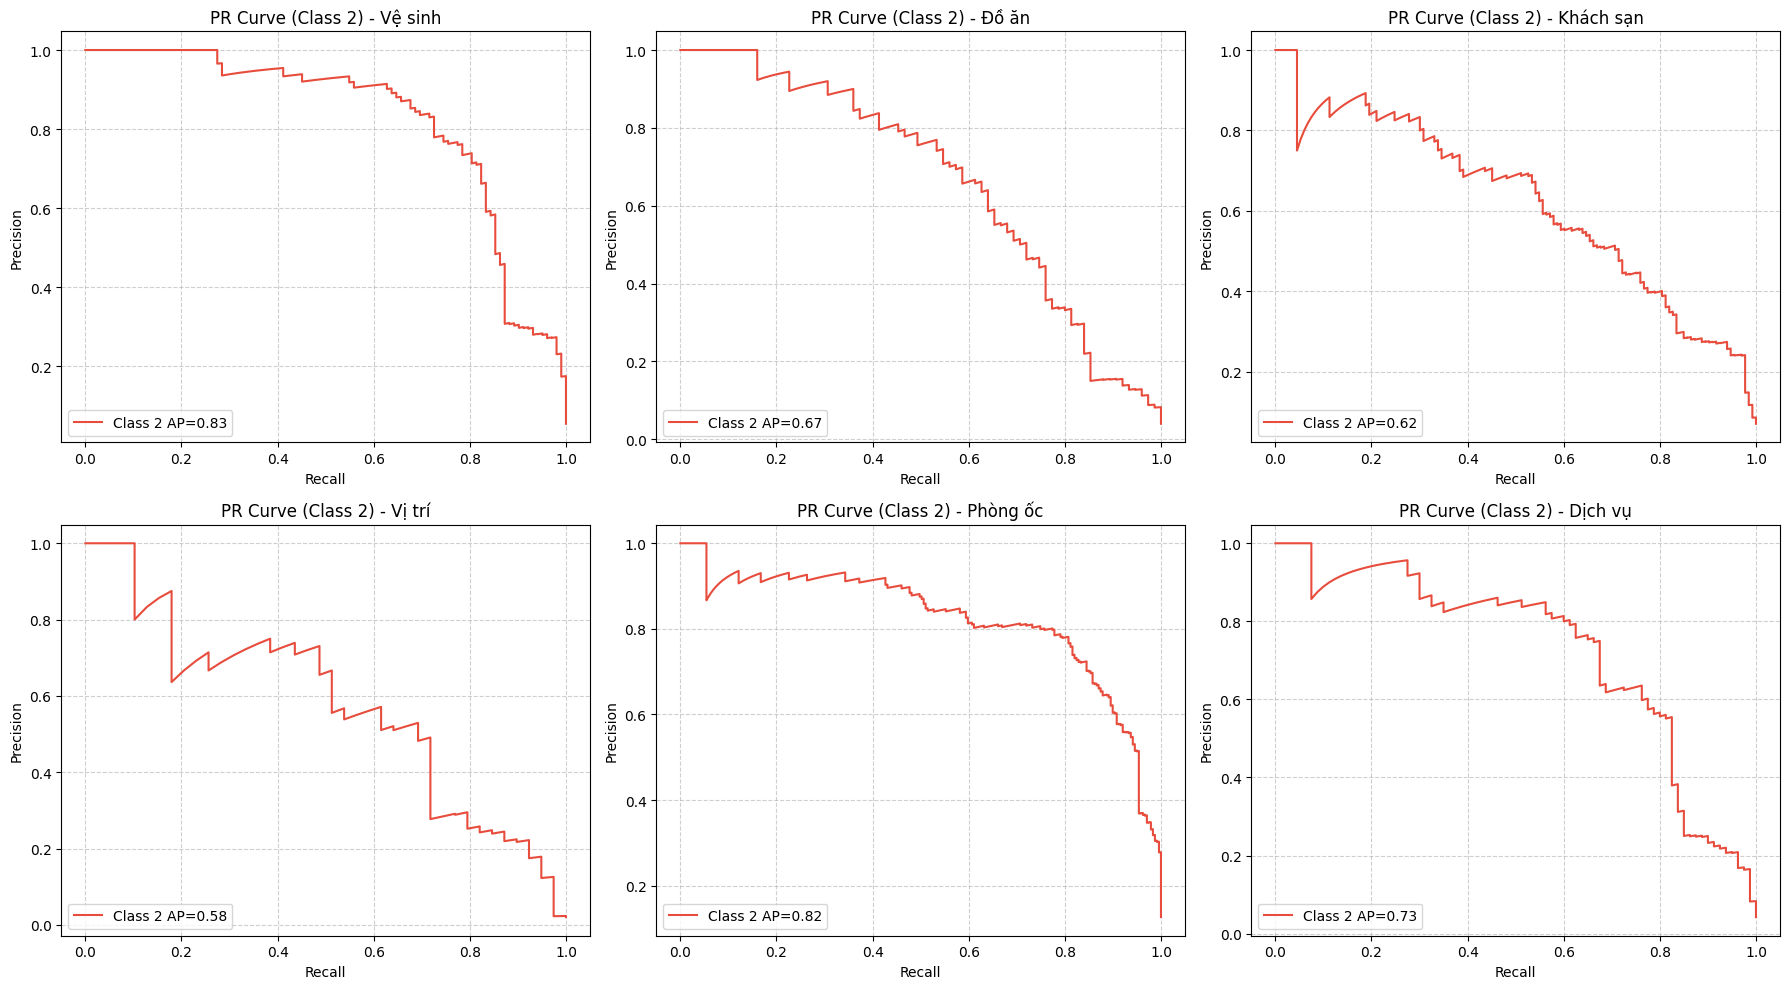

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Check if the model has a decision_function
has_decision = hasattr(model.estimators_[0], 'decision_function')

for i, aspect in enumerate(target_names):
    y_true_i = y_test.iloc[:, i].values if hasattr(y_test, 'iloc') else y_test[:, i]
    
    # Transform the problem into Binary: Focus only on layer 2 (Negative) compared to the rest
    y_true_binary = (y_true_i == 2).astype(int)
    
    # Get a confidence score
    if has_decision:
        # Get the corresponding column for grade 2
        y_score = model.estimators_[i].decision_function(X_test_tfidf)
        if len(y_score.shape) > 1:
            y_score_cls2 = y_score[:, 2] 
        else:
            y_score_cls2 = y_score # Binary case
    else:
        # If the model is an SVC, then probability=True
        y_score_cls2 = model.estimators_[i].predict_proba(X_test_tfidf)[:, 2]

    # Calculate precision - recall
    precision, recall, _ = precision_recall_curve(y_true_binary, y_score_cls2)
    ap = average_precision_score(y_true_binary, y_score_cls2)
    
    # Draw chart
    axes[i].plot(recall, precision, color='#e74c3c', label=f'Class 2 AP={ap:.2f}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_title(f"PR Curve (Class 2) - {aspect.capitalize()}")
    axes[i].legend(loc='lower left')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

The **Precision-Recall (PR) Curve** and **Average Precision (AP)** are adopted as the core evaluation metrics for assessing the performance of detecting **Class 2 (Negative)**. In the context of a **highly imbalanced dataset**, AP provides a more realistic and stringent evaluation than ROC-AUC, as it directly measures the trade-off between **Recall** and **Precision**.

**Cleanliness (0.83) and Room (0.82):**
* The PR curves demonstrate strong robustness, maintaining high Precision even when relaxing the decision threshold to achieve Recall levels around 0.6–0.7.
* These aspects exhibit feature spaces that are highly linearly separable. The negative class is primarily characterized by **local and explicit lexical features** (e.g., “dirty”, “smelly”, “old”). The TF-IDF weights of these n-grams are significantly high, enabling the SVM to effectively optimize the **margin** of the **hyperplane** with minimal noise interference.

**Service (AP = 0.73), Food (AP = 0.67), Hotel (AP = 0.62):**
* Precision declines rapidly at early stages of the Recall axis. Attempts to maximize True Positives lead to a sharp increase in False Positives.
* This reflects a typical limitation of **discrete feature representations** such as Bag-of-Words/TF-IDF. Complaints regarding service or overall hotel experience often involve **complex semantics**, including long-distance negations, sarcasm, and context-dependent expressions. Since TF-IDF ignores **sequential context**, the model fails to capture syntactic and semantic relationships. Consequently, the **decision boundary** becomes highly overlapping, leading to ambiguous prediction regions.

**Location (AP = 0.58)**
* Although the overall macro F1-score for this aspect is relatively high, performance on the minority class (Class 2) is the lowest, with Precision dropping sharply even at very low Recall levels.
* This phenomenon highlights the adverse impact of **extreme class imbalance**. The number of negative samples in the “Location” aspect is severely limited. With sparse data, the SVM cannot learn a sufficient number of representative **support vectors**. As a result, the objective function becomes heavily biased toward the majority class, significantly degrading the model’s **generalization ability** on the minority class in the test set.